In [1]:
import pandas as pd
from dataclasses import asdict
from pathlib import Path
import pickle
import gc

from audit import audit_wrapper, Config as AuditConfig
from normalization import normalization_wrapper, Config as NormalizationConfig
from masking_regex import masking_wrapper as regex_masking_wrapper
from masking_spacy import masking_wrapper as spacy_masking_wrapper, Config as SpacyMaskingConfig
from features_statistical import statistical_features_wrapper, Config as StatisticalConfig
from features_tfidf import tfidf_features_wrapper, Config as TFIDFConfig
from features_ngram import ngram_features_wrapper, Config as NGramConfig
from dimensionality_reduction import dimensionality_reduction_wrapper, Config as ReductionConfig

from helpers import *

BASE_DIR = Path.cwd().parent
SAVE_DIR = BASE_DIR / "saved" # folder to save progress outputs

/Users/salirafi/Documents/Personal Project/Text Similarity/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_from_disk

from pathlib import Path
BASE_DIR = Path.cwd().parent

In [3]:
dict_df = {}
for split in ["train", "validation", "test"]:
    dataset_dir = BASE_DIR / "data/raw" / f"authorship_verification_{split}" # must live under data/raw/ folder in project root
    ds = load_from_disk(dataset_dir)
    df = ds.to_pandas()
    df["__split__"] = split # identify which split
    df["__row_id__"] = df.index
    dict_df[split] = df # dict[str, pd.DataFrame]

In [4]:
plot_df = dict_df["train"].copy()
for col in ["text1", "text2"]:
    plot_df[f"{col}_word_count"] = (plot_df[col].astype(str).str.split().str.len()) # .str.split().str.len() to split on white space and count resulting words

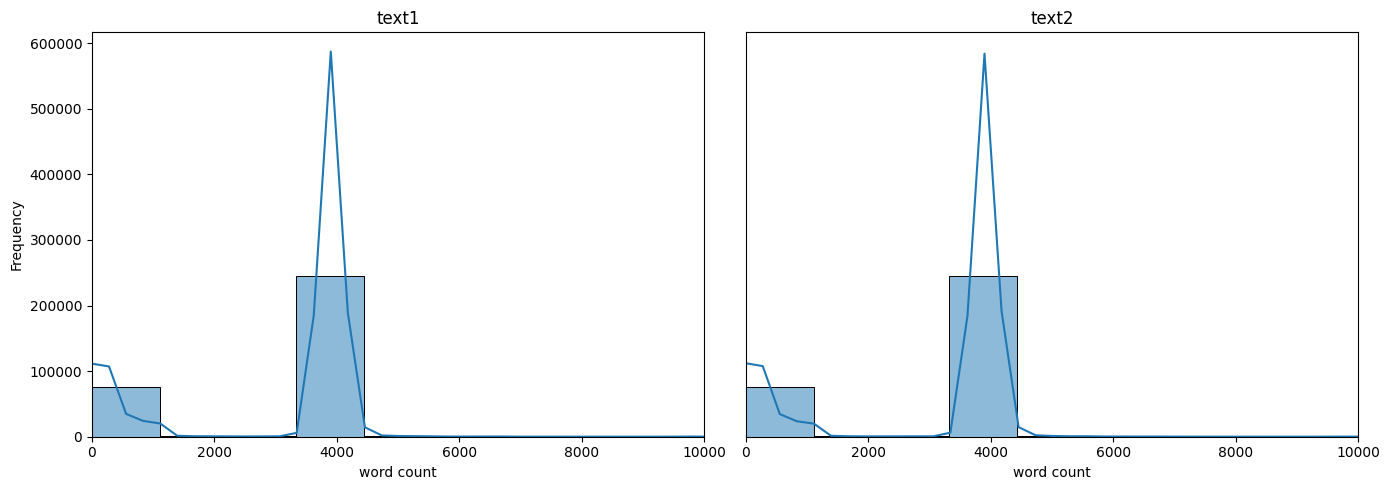

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.subplots_adjust(wspace=0)


sns.histplot(plot_df["text1_word_count"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("text1")
axes[0].set_xlabel("word count")
axes[0].set_ylabel("Frequency")

sns.histplot(plot_df["text2_word_count"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("text2")
axes[1].set_xlabel("word count")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", left=False, labelleft=False)

axes[0].set_xlim(0, 10000) # no significant amout larger than ~4500
axes[1].set_xlim(0, 10000)

plt.tight_layout()
plt.show()

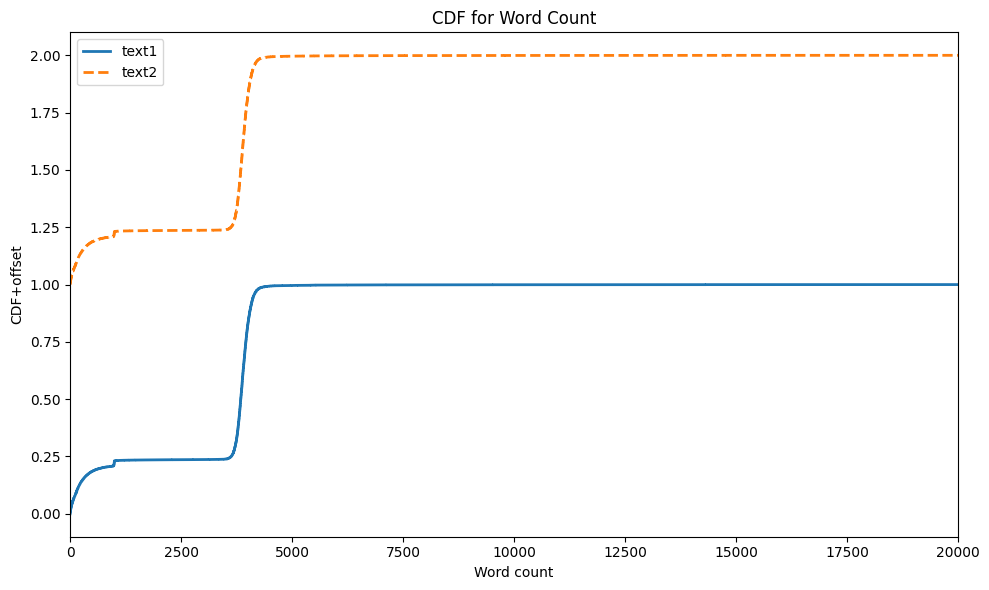

In [10]:
def ecdf(values):
    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

x1, y1 = ecdf(plot_df["text1_word_count"])
x2, y2 = ecdf(plot_df["text2_word_count"])

plt.figure(figsize=(10, 6))
plt.step(x1, y1, where="post", label="text1", lw=2)
plt.step(x2, y2+1, where="post", label="text2", lw=2, ls="--")

plt.title("CDF for Word Count")
plt.xlabel("Word count")
plt.ylabel("CDF+offset")
plt.legend()
plt.xlim(0,20000)
plt.tight_layout()
plt.show()

# Pre-training Process

## Pre-masking

In [2]:
audit_config = AuditConfig(min_words=150, max_words=2000)
df_filtered, audit_summary = audit_wrapper(BASE_DIR / "data/raw", config=audit_config)

# saving
audit_dir = SAVE_DIR / "audit"
save_split_frames(df_filtered, audit_dir / "dataframes", "audit")
save_dataframe(audit_summary, audit_dir / "audit_summary.csv")
save_json(asdict(audit_config), audit_dir / "audit_config.json")

======= AUDIT START =======

Loaded train split: 325288 rows
Loaded validation split: 30781 rows
Loaded test split: 30988 rows

Word-count filter used: min_words=150, max_words=2000

Starting masking rows based on invalid text fields and labels, and word count if specified...

    Processing split='train' (325,288 rows)
    Split='train': remove 292,337 rows, 32,951 rows remain

    Processing split='validation' (30,781 rows)
    Split='validation': remove 23,326 rows, 7,455 rows remain

    Processing split='test' (30,988 rows)
    Split='test': remove 23,486 rows, 7,502 rows remain

Checking for duplicate pairs (same texts and label, regardless of order) before deduplication...
There are 152 duplicate pairs across all splits before deduplication

    Split='train': 32,926 valid rows after deduplication
    Split='validation': 7,444 valid rows after deduplication
    Split='test': 7,386 valid rows after deduplication

Summary statistics for each split:
        split  num_rows  same_0_

In [3]:
normalization_config = NormalizationConfig(unicode_form="NFC")
normalized_dict_df, normalization_summary = normalization_wrapper(df_filtered, config=normalization_config)

normalization_dir = SAVE_DIR / "normalization"
save_split_frames(normalized_dict_df, normalization_dir / "dataframes", "normalized")
save_dataframe(normalization_summary, normalization_dir / "normalization_summary.csv")
save_json(asdict(normalization_config), normalization_dir / "normalization_config.json")


======= NORMALIZATION START =======

Normalizing split='train' (32,926 rows)
Normalizing split='validation' (7,444 rows)
Normalizing split='test' (7,386 rows)

Normalization summary:
        split  num_rows  text1_mean_word_length  text1_mean_char_length  \
0       train     32926                  539.08                 2763.19   
1  validation      7444                  542.21                 2785.82   
2        test      7386                  539.63                 2766.97   

   text2_mean_word_length  text2_mean_char_length  
0                  534.74                 2740.48  
1                  540.61                 2775.54  
2                  536.93                 2750.20  

======= NORMALIZATION END =======



In [5]:
del df_filtered, normalized_dict_df
gc.collect()

31

## Masking

### Regex masking

In [7]:
# loading normalized df
normalized_dict_df = {split: pd.read_parquet(SAVE_DIR / f"normalization/dataframes/{split}_normalized.parquet") for split in ["train", "validation", "test"]}

In [3]:
regex_masked_dict_df, regex_masking_summary = regex_masking_wrapper(normalized_dict_df) # config only verbose=True

# saving
masking_dir = SAVE_DIR / "masking"
save_split_frames(regex_masked_dict_df, masking_dir / "dataframes", "regex_masked")
save_dataframe(regex_masking_summary, masking_dir / "regex_masking_summary.csv")

======= REGEX MASKING START =======

Regex masking split='train' (32,926 rows)
    Replacement counts: URL=749, EMAIL=150, DATE=390, TIME=1,308, CURRENCY=68, ADDRESS=53, ORG_SUFFIX=11,190, NUMBER=21,439

Regex masking split='validation' (7,444 rows)
    Replacement counts: URL=342, EMAIL=37, DATE=90, TIME=247, CURRENCY=38, ADDRESS=6, ORG_SUFFIX=2,449, NUMBER=6,427

Regex masking split='test' (7,386 rows)
    Replacement counts: URL=527, EMAIL=66, DATE=89, TIME=434, CURRENCY=12, ADDRESS=15, ORG_SUFFIX=2,414, NUMBER=5,166

Regex masking summary:
        split  num_rows  url_count  email_count  date_count  time_count  \
0       train     32926        749          150         390        1308   
1  validation      7444        342           37          90         247   
2        test      7386        527           66          89         434   

   currency_count  address_count  org_suffix_count  number_count  
0              68             53             11190         21439  
1              

### SpaCy masking

In [2]:
# loading regex masked df
regex_masked_dict_df = {split: pd.read_parquet(SAVE_DIR / f"masking/dataframes/{split}_regex_masked.parquet") for split in ["train", "validation", "test"]}

In [3]:
spacy_config = SpacyMaskingConfig(
    nlp_model="en_core_web_lg",
    nlp_batch_size=150,
    nlp_n_process=2,
    use_gpu=False,
    checkpoint_dir=SAVE_DIR/"masking/spacy_checkpoints"
)
spacy_masked_dict_df, spacy_masking_summary, linguistic_cache = spacy_masking_wrapper(regex_masked_dict_df, config=spacy_config)
 
 # saving
masking_dir = SAVE_DIR / "masking"
save_split_frames(spacy_masked_dict_df, masking_dir / "dataframes", "spacy_masked")
save_dataframe(spacy_masking_summary, masking_dir / "spacy_masking_summary.csv")
save_json(asdict(spacy_config), masking_dir / "spacy_config.json")
with open(masking_dir / "linguistic_cache.pkl", "wb") as f:
    pickle.dump(linguistic_cache, f)

======= SPACY MASKING START =======

Loading spaCy model 'en_core_web_lg' with NER, tagger, parser, senter, and lemmatizer enabled.

Processing spaCy masking column='text1' across all splits
  spaCy masking split='train' (32,926 rows)


spaCy masking [train:text1]: 100%|█████████▉| 32925/32926 [20:49<00:00, 26.35it/s] 


  spaCy masking split='validation' (7,444 rows)


spaCy masking [validation:text1]: 100%|█████████▉| 7443/7444 [04:55<00:00, 25.19it/s]


  spaCy masking split='test' (7,386 rows)


...

  spaCy masking split='validation' (7,444 rows)


spaCy masking [validation:text2]: 100%|█████████▉| 7443/7444 [04:55<00:00, 25.22it/s]


  spaCy masking split='test' (7,386 rows)


spaCy masking [test:text2]: 100%|█████████▉| 7385/7386 [04:48<00:00, 25.61it/s]



Saved spaCy checkpoint for column='text2' to '/Users/salirafi/Documents/Personal Project/Text Similarity/saved/masking/spacy_checkpoints/text2'.

spaCy masking summary:
        split  num_rows  CARDINAL_count  DATE_count  EVENT_count  FAC_count  \
0       train     32926           22619       31060         1849       3210   
1  validation      7444            5337        6855          492        887   
2        test      7386            5101        6706          403        836   

   GPE_count  LANGUAGE_count  LAW_count  LOC_count  MONEY_count  NORP_count  \
0      39790            4703       1023       4765          795       22442   
1       9384            1564        243       1186          192        5656   
2       8679            1667        210       1114          178        5322   

   ORDINAL_count  ORG_count  PERCENT_count  PERSON_count  PRODUCT_count  \
0           4516     358189             47        218107           6731   
1           1234      83152             12    

## Feature Extraction

### Statistical features

In [2]:
# load spaCy outputs
masking_dir = SAVE_DIR / "masking"
spacy_masked_dict_df = {split: pd.read_parquet(masking_dir / f"dataframes/{split}_spacy_masked.parquet") for split in ["train", "validation", "test"]}
with open(masking_dir / "linguistic_cache.pkl", "rb") as f:
    linguistic_cache = pickle.load(f)

In [3]:
statistical_config = StatisticalConfig(
    include_function_word_rate = True,
    exclude_placeholders_from_avg_word_length = True,
    phrase_role_dependency_labels = ("acl", "advcl", "ccomp", "pcomp", "relcl", "xcomp")
)
statistical_dict_df, statistical_summary_df = statistical_features_wrapper(spacy_masked_dict_df, linguistic_cache, config=statistical_config)

statistical_dir = SAVE_DIR / "statistical_features"
save_split_frames(statistical_dict_df, statistical_dir / "dataframes", "statistical")
save_dataframe(statistical_summary_df, statistical_dir / "statistical_summary.csv")
save_json(asdict(statistical_config), masking_dir / "statistical_config.json")

======= STATISTICAL FEATURES START =======

Processing statistical features for split='train' (32,926 rows)


Stat features [train:text2]: 100%|██████████| 32926/32926 [00:45<00:00, 729.05it/s] 



Processing statistical features for split='validation' (7,444 rows)


Stat features [validation:text2]: 100%|██████████| 7444/7444 [00:10<00:00, 723.61it/s] 



Processing statistical features for split='test' (7,386 rows)


Stat features [test:text2]: 100%|██████████| 7386/7386 [00:10<00:00, 729.23it/s] 



Statistical feature summary:
        split  num_rows  text1_avg_sentence_length_words_mean  \
0       train     32926                             47.972813   
1  validation      7444                             47.608920   
2        test      7386                             46.762222   

   text1_avg_function_words_per_sentence_mean  text1_function_word_rate_mean  \
0                                   23.499781                       0.452505   
1                                   23.340878                       0.449187   
2                                   22.857886                       0.450079   

   text1_punctuation_rate_mean  text1_avg_word_length_mean  \
0                     0.101291                    4.211775   
1                     0.101753                    4.228546   
2                     0.100987                    4.225263   

   text2_avg_sentence_length_words_mean  \
0                             47.900930   
1                             46.197069   
2         

### TF-IDF features

In [2]:
# load statistical extraction outputs
statistical_dir = SAVE_DIR / "statistical_features"
statistical_dict_df = {split: pd.read_parquet(statistical_dir / f"dataframes/{split}_statistical.parquet") for split in ["train", "validation", "test"]}

# loading spaCy linguistic cache
masking_dir = SAVE_DIR / "masking"
with open(masking_dir / "linguistic_cache.pkl", "rb") as f:
    linguistic_cache = pickle.load(f)

In [3]:
tfidf_config = TFIDFConfig(
    allowed_pos_tags=("NOUN", "PROPN", "VERB", "ADJ", "ADV", "CONJ", "AUX"),
    min_token_length=2,
    ngram_range=(1,2), #
    min_df=2,
    max_df=0.95, # in text proportion,
    max_features=25000,
    sublinear_tf=True,
    norm="l2",
    dense_output=True,
)
tfidf_dict_df, tfidf_summary_df, tfidf_artifacts = tfidf_features_wrapper(statistical_dict_df, linguistic_cache, config=tfidf_config)


tfidf_dir = SAVE_DIR / "tfidf_features"
save_split_frames(tfidf_dict_df, tfidf_dir / "dataframes", "tfidf")
save_dataframe(tfidf_summary_df, tfidf_dir / "tfidf_summary.csv")
save_json(asdict(tfidf_config), tfidf_dir / "tfidf_config.json")

# saving artifacts
save_json(tfidf_artifacts["feature_names"], tfidf_dir / "feature_names.json")
save_json(tfidf_artifacts["train_corpus_by_column"], tfidf_dir / "train_corpus_by_column.json")
save_json(tfidf_artifacts["corpus_by_split"], tfidf_dir / "corpus_by_split.json")
save_pickle(tfidf_artifacts["vectorizer"], tfidf_dir / "vectorizer.pkl")

======= TF-IDF FEATURES START =======

Building TF-IDF training corpus from train/text1 + train/text2...


TF-IDF prep [train:text2]: 100%|██████████| 32926/32926 [00:08<00:00, 3763.04it/s]
/Users/salirafi/Documents/Personal Project/Text Similarity/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



Fitted TF-IDF vocabulary size: 25,000

Transforming split='train' (32,926 rows)


TF-IDF prep [train:text2]: 100%|██████████| 32926/32926 [00:08<00:00, 3725.52it/s]



Transforming split='validation' (7,444 rows)


TF-IDF prep [validation:text2]: 100%|██████████| 7444/7444 [00:02<00:00, 3683.92it/s]



Transforming split='test' (7,386 rows)


TF-IDF prep [test:text2]: 100%|██████████| 7386/7386 [00:02<00:00, 3625.75it/s]



TF-IDF summary:
        split  num_rows  vocabulary_size  text1_avg_nonzero_features  \
0       train     32926            25000                   165.89510   
1  validation      7444            25000                   163.32147   
2        test      7386            25000                   163.21568   

   text2_avg_nonzero_features  
0                   164.58382  
1                   163.35425  
2                   162.74682  

======= TF-IDF FEATURES END =======



### n-gram features

In [2]:
# load TF-IDF outputs
tfidf_dir = SAVE_DIR / "tfidf_features"
tfidf_dict_df = {split: pd.read_parquet(tfidf_dir / f"dataframes/{split}_tfidf.parquet") for split in ["train", "validation", "test"]}

# loading spaCy linguistic cache
masking_dir = SAVE_DIR / "masking"
with open(masking_dir / "linguistic_cache.pkl", "rb") as f:
    linguistic_cache = pickle.load(f)

In [4]:
ngram_config = NGramConfig(
    char_ngram_n=4,
    char_tfidf_min_df=2,
    char_tfidf_max_df=0.95, # text proportion
    char_tfidf_max_features=50000,

    pos_ngram_range=(2,3),
    pos_tfidf_min_df=2,
    pos_tfidf_max_df=0.95, # text proportion
    pos_tfidf_max_features=5000,

    sublinear_tf=True,
    norm="l2",
    include_readability=True,
    dense_output=True,
)

ngram_dict_df, ngram_summary_df, ngram_artifacts = ngram_features_wrapper(tfidf_dict_df, linguistic_cache, config=ngram_config)

ngram_dir = SAVE_DIR / "ngram_features"
save_split_frames(ngram_dict_df, ngram_dir / "dataframes", "ngram")
save_dataframe(ngram_summary_df, ngram_dir / "ngram_summary.csv")
save_json(asdict(ngram_config), ngram_dir / "ngram_config.json")

save_json(ngram_artifacts["char_feature_names"], ngram_dir / "char_feature_names.json")
save_json(ngram_artifacts["pos_feature_names"], ngram_dir / "pos_feature_names.json")
save_json(ngram_artifacts["train_char_corpus"], ngram_dir / "train_char_corpus.json")
save_json(ngram_artifacts["char_corpus_by_split"], ngram_dir / "char_corpus_by_split.json")
save_json(ngram_artifacts["train_pos_corpus"], ngram_dir / "train_pos_corpus.json")
save_json(ngram_artifacts["pos_corpus_by_split"], ngram_dir / "pos_corpus_by_split.json")
save_pickle(ngram_artifacts["char_vectorizer"], ngram_dir / "char_vectorizer.pkl")
save_pickle(ngram_artifacts["pos_vectorizer"], ngram_dir / "pos_vectorizer.pkl")

======= N-GRAM FEATURES START =======

Building character 4-gram training corpus from train/text1 + train/text2...


Char4 prep [train:text2]: 100%|██████████| 32926/32926 [00:03<00:00, 8440.27it/s] 
/Users/salirafi/Documents/Personal Project/Text Similarity/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



Fitted character 4-gram vocabulary size: 50,000

Building POS n-gram training corpus from train/text1 + train/text2...


POS prep [train:text2]: 100%|██████████| 32926/32926 [00:00<00:00, 48317.21it/s]



Fitted POS (2, 3)-gram vocabulary size: 4,586

Transforming split='train' (32,926 rows)


...


Transforming split='validation' (7,444 rows)


POS prep [validation:text2]: 100%|██████████| 7444/7444 [00:00<00:00, 33778.63it/s]



Transforming split='test' (7,386 rows)


POS prep [test:text2]: 100%|██████████| 7386/7386 [00:00<00:00, 46856.79it/s]



N-gram summary:
        split  num_rows  char_vocabulary_size  pos_vocabulary_size  \
0       train     32926                 50000                 4586   
1  validation      7444                 50000                 4586   
2        test      7386                 50000                 4586   

   text1_char_avg_nonzero_features  text1_pos_avg_nonzero_features  \
0                       571.149335                      329.262862   
1                       574.405696                      328.219640   
2                       568.928784                      328.087057   

   text2_char_avg_nonzero_features  text2_pos_avg_nonzero_features  
0                       567.999636                      327.593027  
1                       572.434041                      327.646427  
2                       566.405768                      326.157866  

======= N-GRAM FEATURES END =======



In [5]:
ngram_dict_df["train"].head()

,text1,text2,same,text1_avg_sentence_length_words,text1_avg_function_words_per_sentence,text1_punctuation_rate,text1_avg_word_length,text1_function_word_rate,text1_phrase_noun_phrase_rate,text1_phrase_prepositional_phrase_rate,...,"text2_pos(2, 3)_tfidf_04584","text2_pos(2, 3)_tfidf_04585",text1_readability_flesch_kincaid_grade,text1_readability_gunning_fog,text1_readability_smog,text1_readability_coleman_liau,text2_readability_flesch_kincaid_grade,text2_readability_gunning_fog,text2_readability_smog,text2_readability_coleman_liau
0,Any real interaction process produces many inc...,A quite general interaction process of a multi...,1,32.714,8.857,0.199,6.079,0.271,0.644,0.287,...,0.0,0.0,23.38060,26.10554,22.19877,21.72727,24.54580,29.99210,24.72125,21.03415
1,"We study the use of ""sign alpha-stable random ...",Based on alpha-stable random projections with ...,1,26.000,7.833,0.188,5.647,0.301,0.591,0.333,...,0.0,0.0,14.61040,17.41884,15.53285,18.39433,13.76660,16.99447,15.11226,14.16585
2,"Currently, organizations are transforming thei...","Currently, cryptography is in wide use as it i...",1,26.429,8.714,0.147,6.157,0.330,0.654,0.167,...,0.0,0.0,21.38167,24.45537,20.89075,20.48701,14.75224,17.61582,15.90319,14.99103
3,In this paper we investigate the opportunities...,We study a general relativistic gravitomagneti...,1,43.667,17.833,0.087,5.225,0.408,0.555,0.336,...,0.0,0.0,22.89159,26.95873,22.07614,14.52063,19.33871,22.29247,19.11799,16.11183
4,We analytically work out the long-term orbital...,There is significant concern that technologica...,0,34.625,10.625,0.132,4.646,0.307,0.602,0.361,...,0.0,0.0,19.94082,23.96681,19.62038,13.88870,11.69527,15.76988,14.37465,12.01807


# Dimensionality Reduction

Not used for the current pipeline.

In [ ]:
# # load n-gram outputs
# ngram_dir = SAVE_DIR / "ngram_features"
# ngram_dict_df = {split: pd.read_parquet(ngram_dir / f"dataframes/{split}_ngram.parquet") for split in ["train", "validation", "test"]}

In [ ]:
# reduction_config = ReductionConfig(
#     tfidf_components=5000,
#     char_components=10000,
#     pos_components=3000,
# )
# reduced_dict_df, reduction_summary_df, reduction_artifacts = dimensionality_reduction_wrapper(ngram_dict_df, config=reduction_config)

# reduction_dir = SAVE_DIR / "dimensionality_reduction"
# save_split_frames(reduced_dict_df, reduction_dir / "dataframes", "reduced")
# save_dataframe(reduction_summary_df, reduction_dir / "reduction_summary.csv")
# save_json(asdict(reduction_config), reduction_dir / "reduction_config.json")

# # saving artifacts
# save_json(reduction_artifacts["family_suffixes"], reduction_dir / "family_suffixes.json")
# save_pickle(reduction_artifacts["svd_models"], reduction_dir / "svd_models.pkl")


======= DIMENSIONALITY REDUCTION START =======

Fitting TruncatedSVD for family='tfidf' with 25,000 base features
    Transforming split='train' for family='tfidf'
    Transforming split='validation' for family='tfidf'
    Transforming split='test' for family='tfidf'
    Reduced family='tfidf' to 5000 components (explained variance sum=0.6544)

Fitting TruncatedSVD for family='char_ngrams' with 50,000 base features
    Transforming split='train' for family='char_ngrams'
    Transforming split='validation' for family='char_ngrams'
    Transforming split='test' for family='char_ngrams'
    Reduced family='char_ngrams' to 10000 components (explained variance sum=0.9083)

Fitting TruncatedSVD for family='pos_ngrams' with 4,586 base features
    Transforming split='train' for family='pos_ngrams'
    Transforming split='validation' for family='pos_ngrams'
    Transforming split='test' for family='pos_ngrams'
    Reduced family='pos_ngrams' to 3000 components (explained variance sum=0.9903)



In [ ]:
def load_reduction_artifacts(artifact_dir: str | Path):
    artifact_dir = Path(artifact_dir)

    with open(artifact_dir / "family_suffixes.json", "r", encoding="utf-8") as f:
        family_suffixes = json.load(f)

    with open(artifact_dir / "svd_models.pkl", "rb") as f:
        svd_models = pickle.load(f)

    return {
        "svd_models": svd_models,
        "family_suffixes": family_suffixes,
    }

def load_reduced_dict_df(artifact_dir: str | Path) -> dict[str, pd.DataFrame]:
    artifact_dir = Path(artifact_dir)
    splits_dir = artifact_dir / "reduced_splits"

    reduced_dict_df = {}
    for path in splits_dir.glob("*.parquet"):
        reduced_dict_df[path.stem] = pd.read_parquet(path)

    return reduced_dict_df

reduced_dict_df = load_reduced_dict_df("artifacts/dimensionality_reduction")